# Day 08. Exercise 02
# Multiclass classification. One-hot encoding. Random forest

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.multiclass import OneVsRestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import matplotlib.pyplot as plt

## 1. Preprocessing

1. Read the file [`checker-submits.csv`](https://drive.google.com/file/d/14voc4fNJZiLEFaZyd8nEG-lQt5JjatYw/view?usp=sharing).
2. Create a dataframe `df` with the columns: `uid`, `labname`, `numTrials`, `hour`, `dayofweek` where `hour` is extracted from the `timestamp` as well as the `dayofweek` (`0` is Monday, `6` is Sunday). We will try to predict the day of the week having data about which user made a commit for which lab at which hour and which try it was.
3. Using `OneHotEncoder()` transform your categorical features, delete from the dataframe the initial columns.
4. Use `StandardScaler()` and scale your continuous features.
5. Save the dataframe as `dayofweek.csv`.
6. Before trying out different algorithms, find out the accuracy of the naive algorithms – the one that predicts everything as the most popular class.

In [2]:
df = pd.read_csv('../data/checker_submits.csv')
df.head()

,uid,labname,numTrials,timestamp
0,user_4,project1,1,2020-04-17 05:19:02.744528
1,user_4,project1,2,2020-04-17 05:22:45.549397
2,user_4,project1,3,2020-04-17 05:34:24.422370
3,user_4,project1,4,2020-04-17 05:43:27.773992
4,user_4,project1,5,2020-04-17 05:46:32.275104


In [3]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['dayofweek'] = df['timestamp'].dt.dayofweek
df['hour'] = df['timestamp'].dt.hour
df = df[['uid', 'labname', 'numTrials', 'hour', 'dayofweek']]
df.head()

,uid,labname,numTrials,hour,dayofweek
0,user_4,project1,1,5,4
1,user_4,project1,2,5,4
2,user_4,project1,3,5,4
3,user_4,project1,4,5,4
4,user_4,project1,5,5,4


In [4]:
cat_feats = ['uid', 'labname']
encoder = OneHotEncoder(sparse=False)
encoded = encoder.fit_transform(df[cat_feats])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names(input_features=cat_feats),
    index=df.index
)

encoded_df.head()

,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,uid_user_15,uid_user_16,uid_user_17,...,labname_lab02,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [5]:
df = df.drop(columns=cat_feats)
df = pd.concat([df, encoded_df], axis=1)

In [6]:
num_feats = ['numTrials', 'hour']
df[num_feats] = StandardScaler().fit_transform(df[num_feats])

In [7]:
df.to_csv('../data/dayofweek.csv', index=False)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1686 entries, 0 to 1685
Data columns (total 44 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   numTrials         1686 non-null   float64
 1   hour              1686 non-null   float64
 2   dayofweek         1686 non-null   int64  
 3   uid_user_0        1686 non-null   float64
 4   uid_user_1        1686 non-null   float64
 5   uid_user_10       1686 non-null   float64
 6   uid_user_11       1686 non-null   float64
 7   uid_user_12       1686 non-null   float64
 8   uid_user_13       1686 non-null   float64
 9   uid_user_14       1686 non-null   float64
 10  uid_user_15       1686 non-null   float64
 11  uid_user_16       1686 non-null   float64
 12  uid_user_17       1686 non-null   float64
 13  uid_user_18       1686 non-null   float64
 14  uid_user_19       1686 non-null   float64
 15  uid_user_2        1686 non-null   float64
 16  uid_user_20       1686 non-null   float64


In [9]:
most_popular = df['dayofweek'].value_counts().idxmax()
naive_pred = [most_popular] * len(df)
print("Naive accuracy:", accuracy_score(df['dayofweek'], naive_pred))

Naive accuracy: 0.23487544483985764


## 2. Algorithms

### a. Logreg

1. Train logistic regression, for the baseline model use `random_state=21`, `fit_intercept=False`. 
2. Calculate the accuracy.
3. Write a function that draws the plot (`barh`) taking coefficients of any trained models, names of the features and the number of `top-n` most important features to display.
4. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model.
5. Remember that it is a multiclass classification and `coef_` returns a matrix, to calculate importance for a feature you need to sum all the individual feature importances for all the target values.

In [10]:
X = df.drop(columns=['dayofweek'])
y = df['dayofweek']

In [11]:
model_log_reg = LogisticRegression(
    random_state=21,
    fit_intercept=False,
    max_iter=1000,
    solver='liblinear',
    multi_class='ovr'
)
model_log_reg.fit(X, y)

LogisticRegression(fit_intercept=False, max_iter=1000, multi_class='ovr',
                   random_state=21, solver='liblinear')

In [12]:
print("Logistic Regression accuracy:", model_log_reg.score(X, y))

Logistic Regression accuracy: 0.6215895610913404


In [13]:
def plot_top_features(coefs, feature_names, top_n=10):
    coef_series = pd.Series(coefs, index=feature_names)
    coef_series = coef_series.abs().sort_values(ascending=False)
    top_features = coef_series.head(top_n)

    plt.figure(figsize=(15,8))
    top_features.sort_values().plot.barh()
    plt.title(f"Top {top_n} most important features")
    plt.xlabel("Importance Level")
    plt.show()

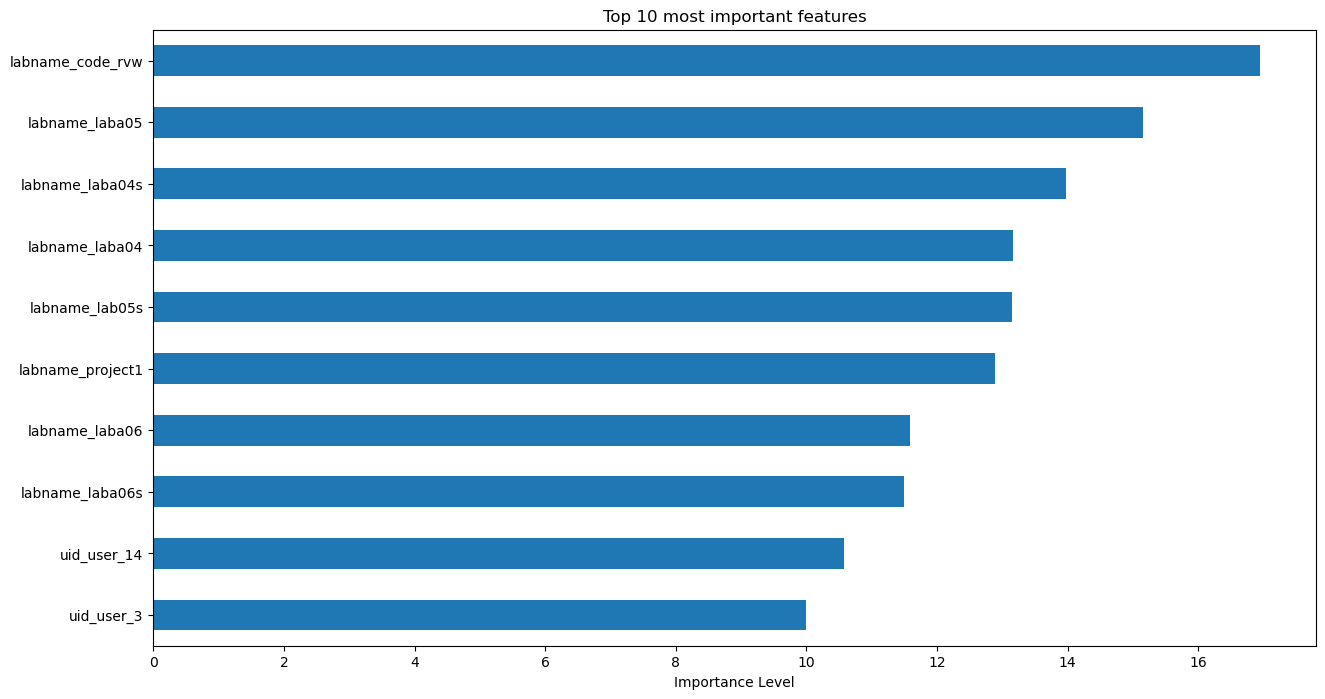

In [14]:
coef_sum = np.abs(model_log_reg.coef_).sum(axis=0)
plot_top_features(coef_sum, X.columns, top_n=10)

### b. SVC

1. Train a `SVC` model, for the baseline model use parameters `kernel='linear'`, `probability=True`, `random_state=21`. 
2. Try different kernels, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model for the linear kernel *

*By default SVC uses “one vs one” strategy of the classification, thus in `coef_` it returns a matrix. To calculate importance for a feature you need to use [OneVsRestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsRestClassifier.html) over the SVC and sum all the individual feature importances for all the target values.

In [15]:
model_svc_base = SVC(kernel='linear', probability=True, random_state=21)
ovr_svc = OneVsRestClassifier(model_svc_base)
ovr_svc.fit(X, y)
print("SVC (linear) accuracy:", ovr_svc.score(X, y))

SVC (linear) accuracy: 0.6115065243179122


In [16]:
for kernel in ['poly', 'rbf', 'sigmoid']:
    clf = SVC(kernel=kernel, probability=True, random_state=21)
    clf.fit(X, y)
    print(f"kernel: '{kernel}', accuracy: {clf.score(X, y)}")

kernel: 'poly', accuracy: 0.8594306049822064
kernel: 'rbf', accuracy: 0.8558718861209964
kernel: 'sigmoid', accuracy: 0.3997627520759193


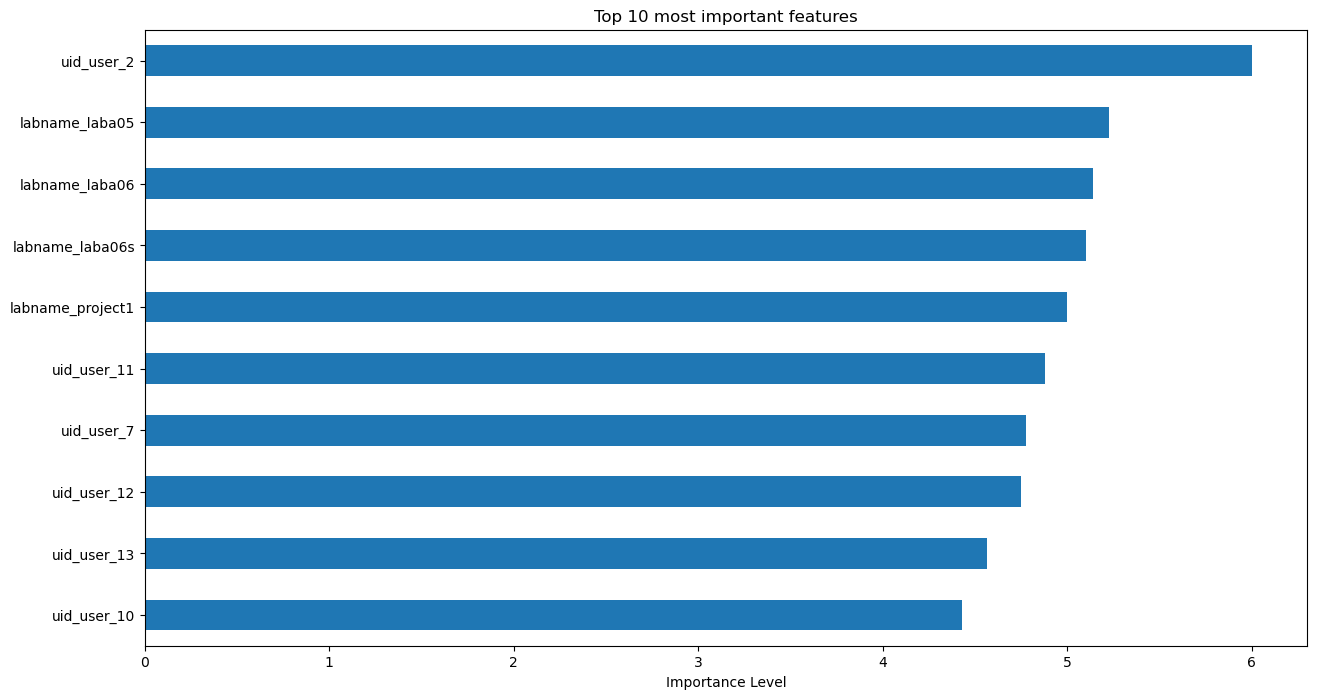

In [17]:
coef_matrix = np.array([est.coef_[0] for est in ovr_svc.estimators_])
svc_importance = np.abs(coef_matrix).sum(axis=0)
plot_top_features(svc_importance, X.columns, top_n=10)

### c. Decision tree

1. Train a `DecisionTreeClassifier` using for the baseline model `max_depth=4`, `random_state=21`. 
2. Try different values of `max_depth`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [18]:
model_dtree = DecisionTreeClassifier(max_depth=4, random_state=21)
model_dtree.fit(X, y)
print("DecisionTree (max_depth=4) accuracy:", model_dtree.score(X, y))

DecisionTree (max_depth=4) accuracy: 0.5516014234875445


In [19]:
for depth in range(1, 26):
    clf = DecisionTreeClassifier(max_depth=depth, random_state=21)
    clf.fit(X, y)
    print(f"max_depth : {depth}, accuracy: {clf.score(X, y)}")

max_depth : 1, accuracy: 0.35765124555160144
max_depth : 2, accuracy: 0.4389086595492289
max_depth : 3, accuracy: 0.48991696322657174
max_depth : 4, accuracy: 0.5516014234875445
max_depth : 5, accuracy: 0.6109134045077106
max_depth : 6, accuracy: 0.6637010676156584
max_depth : 7, accuracy: 0.7064056939501779
max_depth : 8, accuracy: 0.7502965599051008
max_depth : 9, accuracy: 0.7846975088967971
max_depth : 10, accuracy: 0.8196915776986952
max_depth : 11, accuracy: 0.8499406880189798
max_depth : 12, accuracy: 0.8831553973902728
max_depth : 13, accuracy: 0.9104389086595492
max_depth : 14, accuracy: 0.9317912218268091
max_depth : 15, accuracy: 0.9460260972716489
max_depth : 16, accuracy: 0.9608540925266904
max_depth : 17, accuracy: 0.9709371293001187
max_depth : 18, accuracy: 0.9798339264531435
max_depth : 19, accuracy: 0.9839857651245552
max_depth : 20, accuracy: 0.9869513641755635
max_depth : 21, accuracy: 0.9905100830367735
max_depth : 22, accuracy: 0.9922894424673784
max_depth : 23, a

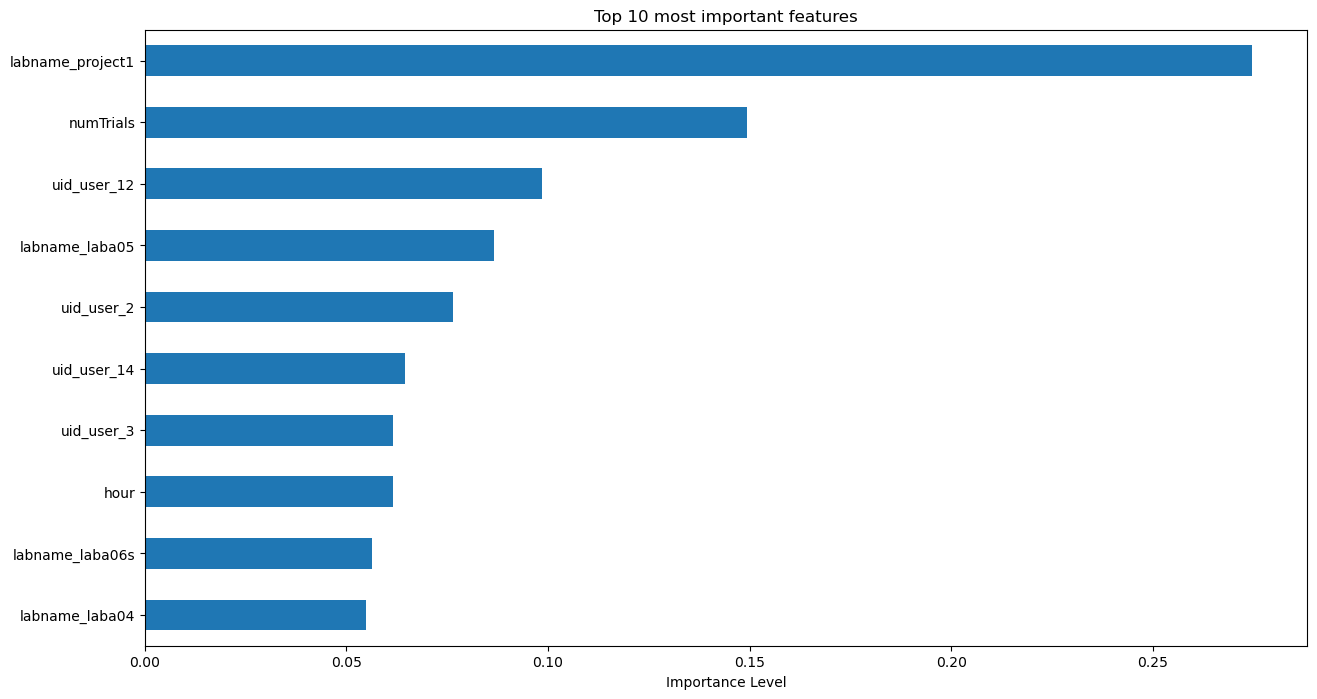

In [20]:
plot_top_features(model_dtree.feature_importances_, X.columns, top_n=10)

### d. Random forest

In real life forest is a set of trees. The same thing is with machine learning. Random forest is a set of individual decision trees (check the documentation for more details).

1. Train a `RandomForestClassifier` using for the baseline model parameters `n_estimators=100`, `max_depth = 25`, `random_state=21`. 
2. Try different values of `max_depth` and `n_estimators`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [21]:
model_random_forest = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)
model_random_forest.fit(X, y)
print("RandomForest accuracy:", model_random_forest.score(X, y))

RandomForest accuracy: 1.0


In [22]:
for max_depth in [1, 5, 10, 20, 30, 40]:
    print(f"\nmax_depth : {max_depth}")
    for n_estimators in [10, 20, 50, 100]:
        clf = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=21
        )
        clf.fit(X, y)
        print(f"  n_estimators: {n_estimators}, accuracy: {clf.score(X, y)}")


max_depth : 1
  n_estimators: 10, accuracy: 0.37129300118623965
  n_estimators: 20, accuracy: 0.3879003558718861
  n_estimators: 50, accuracy: 0.38730723606168443
  n_estimators: 100, accuracy: 0.38730723606168443

max_depth : 5
  n_estimators: 10, accuracy: 0.603202846975089
  n_estimators: 20, accuracy: 0.5830367734282325
  n_estimators: 50, accuracy: 0.5848161328588375
  n_estimators: 100, accuracy: 0.5794780545670225

max_depth : 10
  n_estimators: 10, accuracy: 0.8285883748517201
  n_estimators: 20, accuracy: 0.891459074733096
  n_estimators: 50, accuracy: 0.8701067615658363
  n_estimators: 100, accuracy: 0.8855278766310795

max_depth : 20
  n_estimators: 10, accuracy: 0.9804270462633452
  n_estimators: 20, accuracy: 0.994661921708185
  n_estimators: 50, accuracy: 0.9970344009489917
  n_estimators: 100, accuracy: 0.99644128113879

max_depth : 30
  n_estimators: 10, accuracy: 0.998220640569395
  n_estimators: 20, accuracy: 1.0
  n_estimators: 50, accuracy: 1.0
  n_estimators: 100,

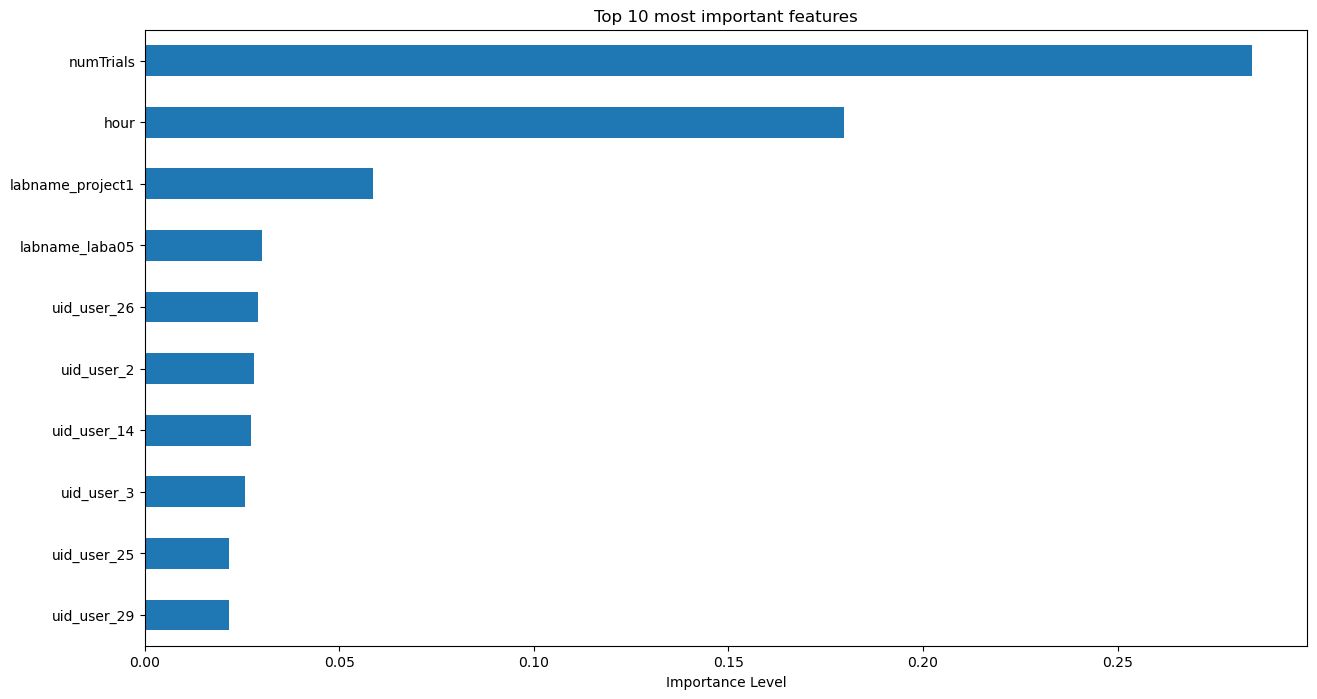

In [23]:
plot_top_features(model_random_forest.feature_importances_, X.columns, top_n=10)